PROJECT-SPORTS ANALYTICS:

IPL 2022 BALL BY BALL ANALYSIS :

**Big Data Analysis of IPL 2022 Ball-by-Ball Dataset using Python in Google Colab**

**Introduction / Explanation**

Cricket generates a large amount of data in every match. In tournaments like the Indian Premier League (IPL), every ball bowled is recorded with detailed information such as runs scored, batsman, bowler, wickets, extras, and teams.

This project performs data analysis on IPL 2022 ball-by-ball data using Python in Google Colab. The dataset contains information for every delivery bowled in IPL matches. By analyzing this data, we can extract insights such as:

Total runs scored in IPL 2022

Top batsmen by runs

Top bowlers by wickets

Team performance

Distribution of runs per ball

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [10]:
df = pd.read_csv("IPL_Ball_by_Ball_2022.csv")
# Create over phase column
def get_phase(over):
    if over <= 5:
        return "Powerplay"
    elif over <= 15:
        return "Middle"
    else:
        return "Death"

df['phase'] = df['overs'].apply(get_phase)

# Total balls faced (excluding extras)
df['legal_ball'] = np.where(df['extra_type'].isna(), 1, 0)
df


,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,phase,legal_ball
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Powerplay,1
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Powerplay,0
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Powerplay,1
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Powerplay,1
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Powerplay,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17907,1304047,2,17,5,SS Iyer,DJ Bravo,SP Jackson,NaN,1,0,1,0,0,NaN,NaN,NaN,Kolkata Knight Riders,Death,1
17908,1304047,2,17,6,SP Jackson,DJ Bravo,SS Iyer,NaN,1,0,1,0,0,NaN,NaN,NaN,Kolkata Knight Riders,Death,1
17909,1304047,2,18,1,SP Jackson,AF Milne,SS Iyer,NaN,1,0,1,0,0,NaN,NaN,NaN,Kolkata Knight Riders,Death,1
17910,1304047,2,18,2,SS Iyer,AF Milne,SP Jackson,NaN,2,0,2,0,0,NaN,NaN,NaN,Kolkata Knight Riders,Death,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17912 entries, 0 to 17911
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 17912 non-null  int64 
 1   innings            17912 non-null  int64 
 2   overs              17912 non-null  int64 
 3   ballnumber         17912 non-null  int64 
 4   batter             17912 non-null  object
 5   bowler             17912 non-null  object
 6   non-striker        17912 non-null  object
 7   extra_type         1050 non-null   object
 8   batsman_run        17912 non-null  int64 
 9   extras_run         17912 non-null  int64 
 10  total_run          17912 non-null  int64 
 11  non_boundary       17912 non-null  int64 
 12  isWicketDelivery   17912 non-null  int64 
 13  player_out         912 non-null    object
 14  kind               912 non-null    object
 15  fielders_involved  704 non-null    object
 16  BattingTeam        17912 non-null  objec

In [ ]:
df.shape

In [ ]:
total_runs = df['total_run'].sum()
print("Total Runs in IPL 2022:", total_runs)

Total Runs in IPL 2022: 24395


In [ ]:
top_batsmen = df.groupby('batter')['batsman_run'].sum().sort_values(ascending=False).head(10)

print(top_batsmen)

batter
JC Buttler      863
KL Rahul        616
Q de Kock       508
HH Pandya       487
Shubman Gill    483
DA Miller       481
F du Plessis    468
S Dhawan        460
SV Samson       458
DJ Hooda        451
Name: batsman_run, dtype: int64


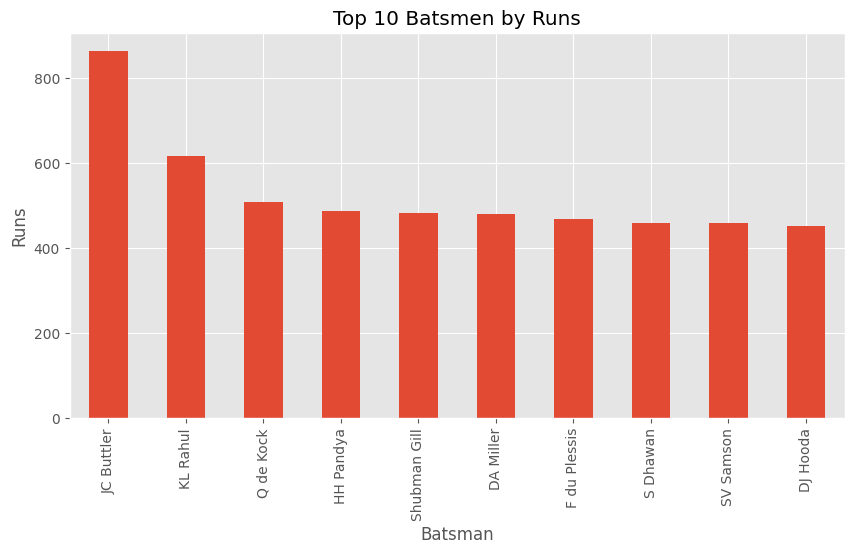

In [ ]:
top_batsmen.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Batsmen by Runs")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()

In [ ]:
wickets = df[df['isWicketDelivery'] == 1]

top_bowlers = wickets.groupby('bowler').size().sort_values(ascending=False).head(10)

print(top_bowlers)

bowler
YS Chahal            29
PWH de Silva         27
Umran Malik          23
K Rabada             23
HV Patel             21
Kuldeep Yadav        21
JR Hazlewood         21
AD Russell           21
Mohammed Shami       21
M Prasidh Krishna    21
dtype: int64


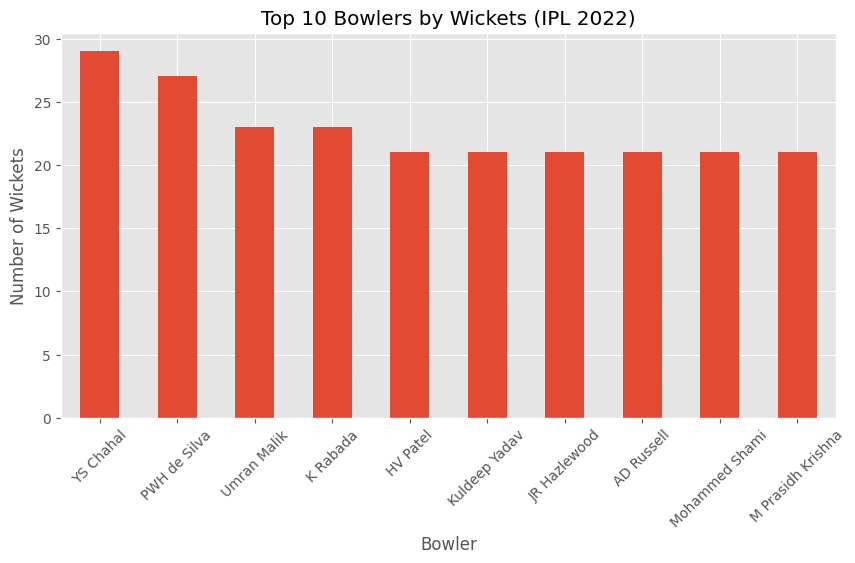

In [ ]:
# Bar graph for top bowlers
top_bowlers.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Bowlers by Wickets (IPL 2022)")
plt.xlabel("Bowler")
plt.ylabel("Number of Wickets")
plt.xticks(rotation=45)

plt.show()

In [ ]:
team_runs = df.groupby('BattingTeam')['total_run'].sum().sort_values(ascending=False)

print(team_runs)

BattingTeam
Rajasthan Royals               2943
Gujarat Titans                 2663
Royal Challengers Bangalore    2632
Lucknow Super Giants           2548
Punjab Kings                   2343
Delhi Capitals                 2341
Chennai Super Kings            2288
Kolkata Knight Riders          2223
Mumbai Indians                 2217
Sunrisers Hyderabad            2197
Name: total_run, dtype: int64


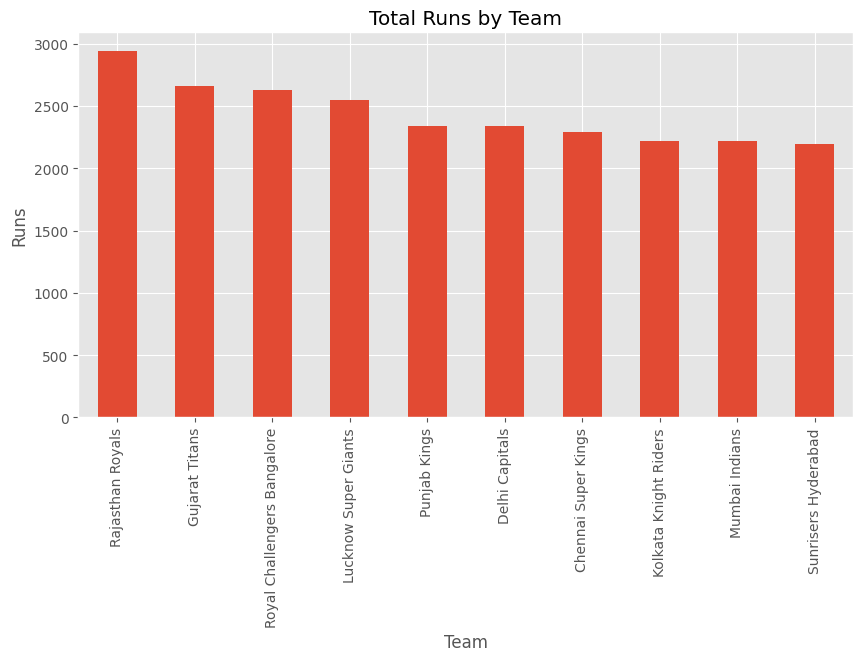

In [ ]:
team_runs.plot(kind='bar', figsize=(10,5))
plt.title("Total Runs by Team")
plt.xlabel("Team")
plt.ylabel("Runs")
plt.show()

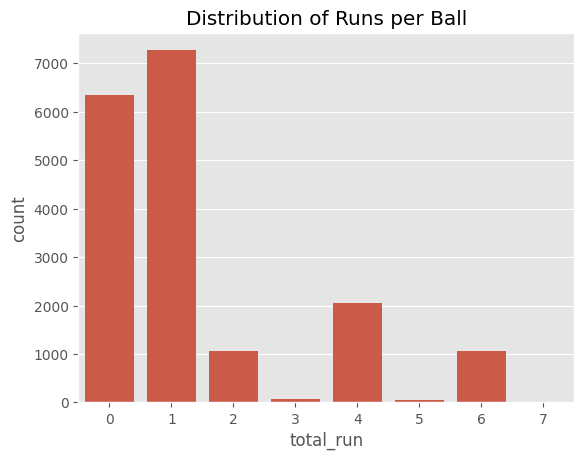

In [ ]:
sns.countplot(x='total_run', data=df)
plt.title("Distribution of Runs per Ball")
plt.show()

This shows that 0s and 1s were scored on most of the balls delivered in TOTAL

The IPL 2022 dataset provides valuable insights into players and teams.
From this analysis we observed that:


•	JC Buttler  Scored the most runs   (863 runs), followed by KL Rahul(616 runs) and Q de kock(508 runs).


•	YS Chahal took the most wickets ( 29), followed by PWH de Silva         (27) and Umran Malik  (23)


•	Rajasthan Royals scored the most runs in 2022 (2943 runs)


•	Most balls result in 0 or 1 run.


             batter      phase  batsman_run  legal_ball  strike_rate
136      KD Karthik      Death          242         108   224.074074
307      SO Hetmyer      Death          218         104   209.615385
18         AR Patel      Death          107          52   205.769231
9        AD Russell      Death          114          56   203.571429
144        KL Rahul      Death          121          60   201.666667
75        DP Conway     Middle          144          82   175.609756
159  LS Livingstone     Middle          301         172   175.000000
270      RM Patidar     Middle          226         130   173.846154
10       AD Russell     Middle          221         131   168.702290
90       GJ Maxwell     Middle          158          98   161.224490
120     JM Bairstow  Powerplay          181         105   172.380952
185          MM Ali  Powerplay          111          67   165.671642
64        DA Warner  Powerplay          225         143   157.342657
229         PP Shaw  Powerplay    

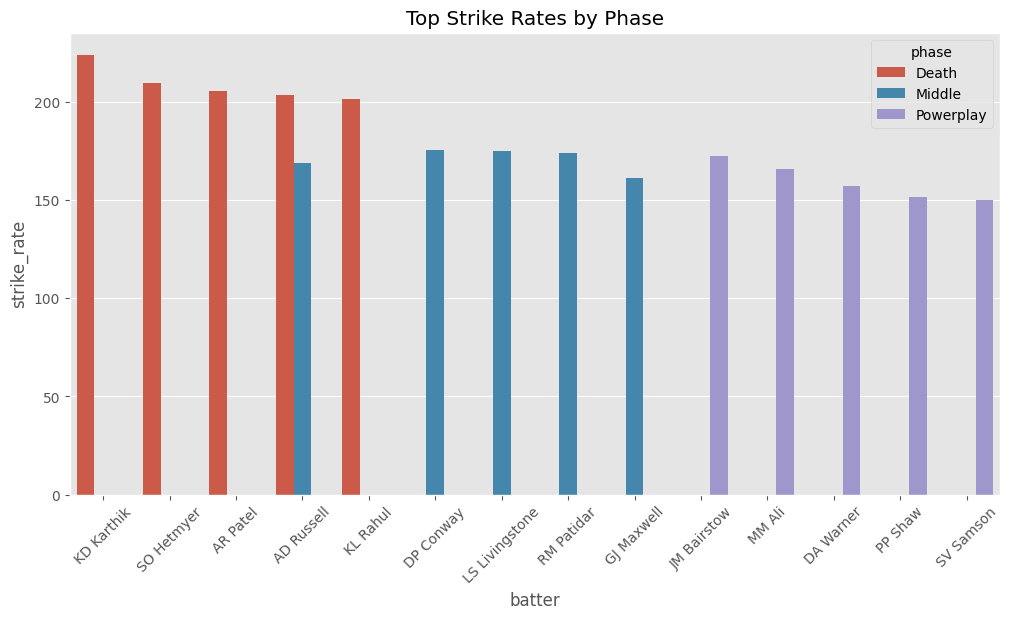

In [11]:
batsman_phase = df.groupby(['batter', 'phase']).agg({
    'batsman_run': 'sum',
    'legal_ball': 'sum'
}).reset_index()

batsman_phase['strike_rate'] = (batsman_phase['batsman_run'] / batsman_phase['legal_ball']) * 100

# Filter players with minimum balls (avoid noise)
batsman_phase = batsman_phase[batsman_phase['legal_ball'] > 50]

# Top players by strike rate in each phase
top_sr = batsman_phase.sort_values(['phase', 'strike_rate'], ascending=[True, False]).groupby('phase').head(5)

print(top_sr)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(data=top_sr, x='batter', y='strike_rate', hue='phase')
plt.title("Top Strike Rates by Phase")
plt.xticks(rotation=45)
plt.show()

             bowler      phase  total_run  legal_ball  overs_bowled   economy
229     Rashid Khan      Death         41          36      6.000000  6.833333
92        JJ Bumrah      Death        129         103     17.166667  7.514563
199    PWH de Silva      Death         45          35      5.833333  7.714286
27   Arshdeep Singh      Death        135          99     16.500000  8.181818
183        OC McCoy      Death         84          59      9.833333  8.542373
166     Mohsin Khan     Middle         44          54      9.000000  4.888889
250       SP Narine     Middle        234         255     42.500000  5.505882
230     Rashid Khan     Middle        329         307     51.166667  6.429967
111       KH Pandya     Middle        184         170     28.333333  6.494118
77         HV Patel     Middle        199         182     30.333333  6.560440
255  Sandeep Sharma  Powerplay         66          71     11.833333  5.577465
167     Mohsin Khan  Powerplay         89          94     15.666

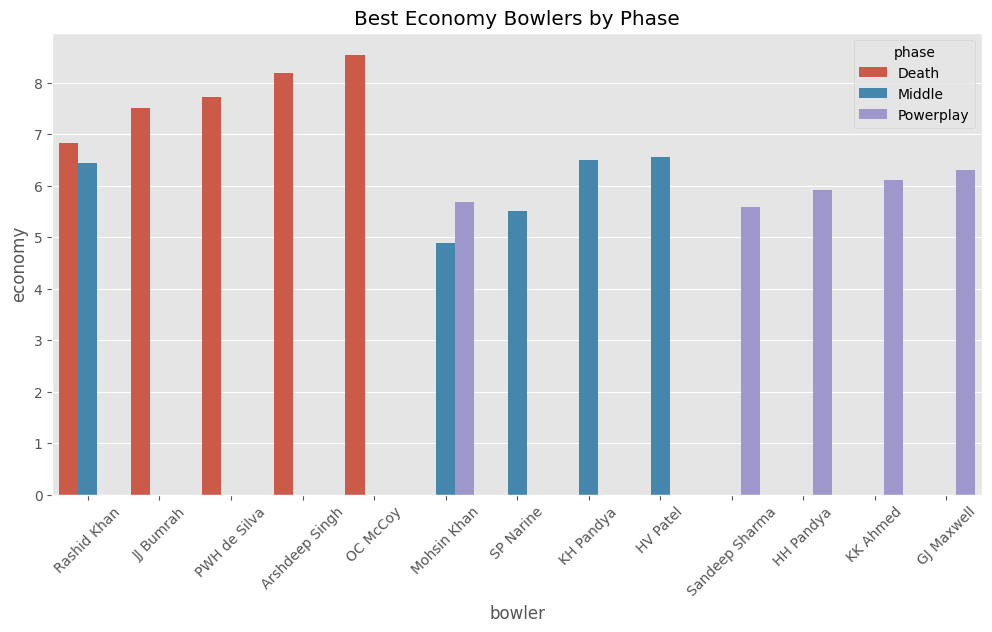

In [12]:
bowler_phase = df.groupby(['bowler', 'phase']).agg({
    'total_run': 'sum',
    'legal_ball': 'sum'
}).reset_index()

bowler_phase['overs_bowled'] = bowler_phase['legal_ball'] / 6
bowler_phase['economy'] = bowler_phase['total_run'] / bowler_phase['overs_bowled']

# Filter meaningful sample
bowler_phase = bowler_phase[bowler_phase['overs_bowled'] > 5]

top_economy = bowler_phase.sort_values(['phase', 'economy']).groupby('phase').head(5)

print(top_economy)

plt.figure(figsize=(12,6))
sns.barplot(data=top_economy, x='bowler', y='economy', hue='phase')
plt.title("Best Economy Bowlers by Phase")
plt.xticks(rotation=45)
plt.show()

                batter   avg_runs   std_dev  consistency_score
32         DJ Mitchell  16.500000  0.707107          23.334524
23           CJ Jordan   5.500000  0.707107           7.778175
51         JDS Neesham  15.500000  2.121320           7.306770
43          HR Shokeen  21.500000  4.949747           4.343656
155    Simarjeet Singh   2.333333  0.577350           4.041452
132    Ramandeep Singh  11.250000  3.593976           3.130238
16    Anmolpreet Singh   6.500000  2.121320           3.064129
77   M Prasidh Krishna   3.000000  1.414214           2.121320
93    Mukesh Choudhary   3.000000  1.414214           2.121320
152     Shashank Singh  13.800000  6.760178           2.041367


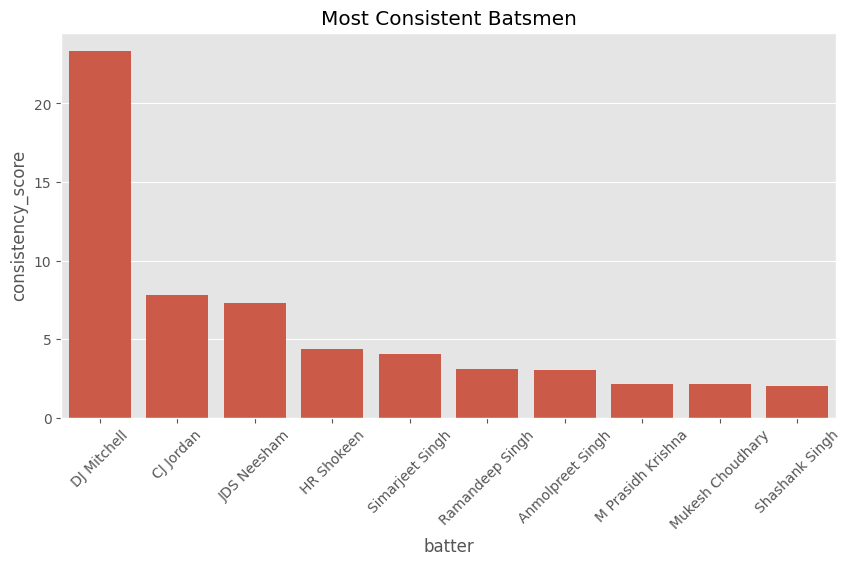

In [13]:
# Runs per match per player
player_match_runs = df.groupby(['ID', 'batter'])['batsman_run'].sum().reset_index()

consistency = player_match_runs.groupby('batter').agg({
    'batsman_run': ['mean', 'std']
}).reset_index()

consistency.columns = ['batter', 'avg_runs', 'std_dev']

# Consistency score (lower std = better consistency)
consistency['consistency_score'] = consistency['avg_runs'] / consistency['std_dev']

# Remove NaN / inf
consistency = consistency.replace([np.inf, -np.inf], np.nan).dropna()

top_consistent = consistency.sort_values('consistency_score', ascending=False).head(10)

print(top_consistent)

plt.figure(figsize=(10,5))
sns.barplot(data=top_consistent, x='batter', y='consistency_score')
plt.title("Most Consistent Batsmen")
plt.xticks(rotation=45)
plt.show()

batter
JC Buttler      350
HH Pandya       339
Shubman Gill    311
RD Gaikwad      291
Ishan Kishan    284
DJ Hooda        278
S Dhawan        260
F du Plessis    260
N Rana          240
SV Samson       240
Name: batsman_run, dtype: int64


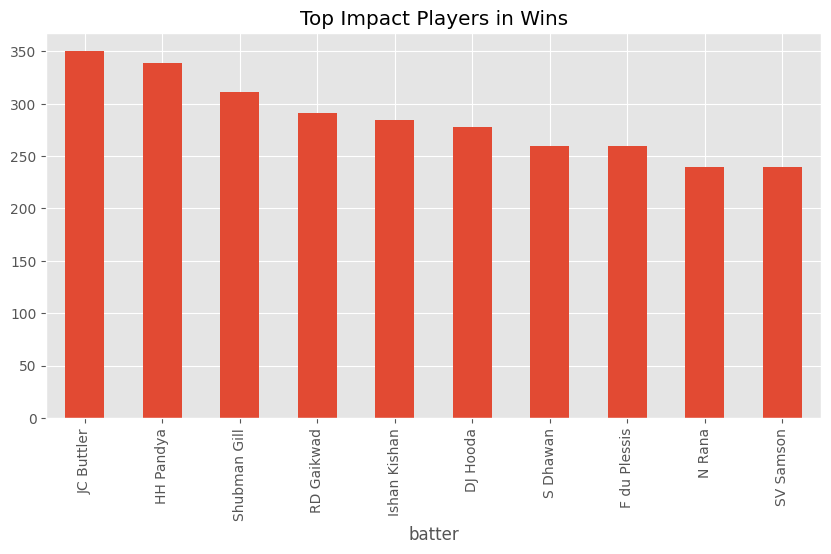

In [15]:
# Runs by player in winning matches
impact_players = df[df['is_winning_team'] == 1].groupby('batter')['batsman_run'].sum().sort_values(ascending=False).head(10)

print(impact_players)

impact_players.plot(kind='bar', figsize=(10,5))
plt.title("Top Impact Players in Wins")
plt.show()

         batter  batsman_run  legal_ball  strike_rate  finisher_score
49   KD Karthik          242         108   224.074074    54225.925926
117  SO Hetmyer          218         104   209.615385    45696.153846
20    DA Miller          174          98   177.551020    30893.877551
38   JC Buttler          123          50   246.000000    30258.000000
95    R Tewatia          158          87   181.609195    28694.252874
131    TH David          114          46   247.826087    28252.173913
71     MS Dhoni          153          86   177.906977    27219.767442
92     R Powell          113          47   240.425532    27168.085106
53     KL Rahul          121          60   201.666667    24401.666667
3    AD Russell          114          56   203.571429    23207.142857


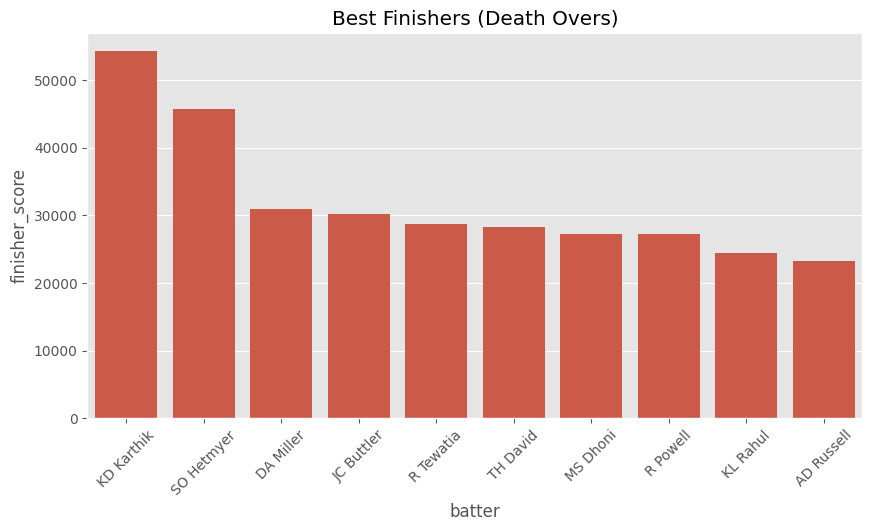

In [16]:
# Filter death overs
death_df = df[df['phase'] == 'Death']

finisher = death_df.groupby('batter').agg({
    'batsman_run': 'sum',
    'legal_ball': 'sum'
}).reset_index()

# Strike rate
finisher['strike_rate'] = (finisher['batsman_run'] / finisher['legal_ball']) * 100

# Filter serious players
finisher = finisher[finisher['legal_ball'] > 30]

# Finisher score (you can tweak this)
finisher['finisher_score'] = finisher['batsman_run'] * finisher['strike_rate']

top_finishers = finisher.sort_values('finisher_score', ascending=False).head(10)

print(top_finishers)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(data=top_finishers, x='batter', y='finisher_score')
plt.title("Best Finishers (Death Overs)")
plt.xticks(rotation=45)
plt.show()

In [17]:
# Create cumulative wickets per match
df['wickets_fallen'] = df.groupby('ID')['isWicketDelivery'].cumsum()

# Define clutch condition
df['is_clutch'] = np.where(
    (df['phase'] == 'Death') | (df['wickets_fallen'] >= 5),
    1, 0
)

           batter  batsman_run  legal_ball  strike_rate  clutch_score
60     KD Karthik          321         162   198.148148  63605.555556
3      AD Russell          323         174   185.632184  59959.195402
27      DA Miller          366         229   159.825328  58496.069869
48     JC Buttler          269         136   197.794118  53206.617647
119   RA Tripathi          296         177   167.231638  49500.564972
141    SO Hetmyer          258         138   186.956522  48234.782609
159   Tilak Varma          324         230   140.869565  45641.739130
28      DA Warner          258         158   163.291139  42129.113924
5      AK Markram          299         215   139.069767  41581.860465
151  Shubman Gill          315         240   131.250000  41343.750000


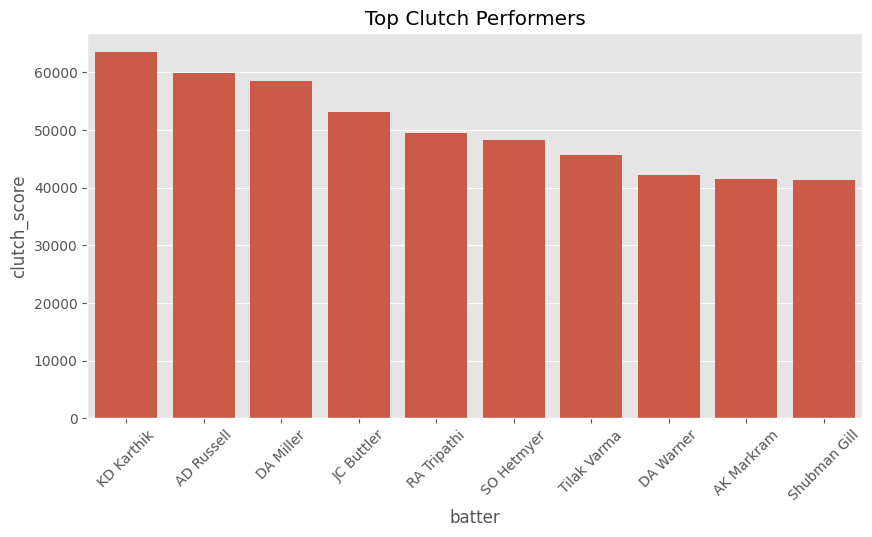

In [18]:
clutch_df = df[df['is_clutch'] == 1]

clutch = clutch_df.groupby('batter').agg({
    'batsman_run': 'sum',
    'legal_ball': 'sum'
}).reset_index()

clutch['strike_rate'] = (clutch['batsman_run'] / clutch['legal_ball']) * 100

# Filter players
clutch = clutch[clutch['legal_ball'] > 30]

# Clutch score
clutch['clutch_score'] = clutch['batsman_run'] * clutch['strike_rate']

top_clutch = clutch.sort_values('clutch_score', ascending=False).head(10)

print(top_clutch)

plt.figure(figsize=(10,5))
sns.barplot(data=top_clutch, x='batter', y='clutch_score')
plt.title("Top Clutch Performers")
plt.xticks(rotation=45)
plt.show()

In [19]:
# Normalize overs (0–20 scale)
df['over_factor'] = df['overs'] / 20

# Normalize wickets (0–10 scale)
df['wicket_factor'] = df['wickets_fallen'] / 10

# Pressure index (weighted)
df['pressure_index'] = (0.6 * df['over_factor']) + (0.4 * df['wicket_factor'])

                batter  batsman_run  legal_ball  pressure_index  strike_rate  \
159           TH David          186          86        0.826154   216.279070   
4           AD Russell          335         187        0.778800   179.144385   
61          KD Karthik          330         176        0.743404   187.500000   
8             AR Patel          182         117        0.807131   155.555556   
143          SN Thakur          120          86        0.879667   139.534884   
170  Washington Sundar          101          68        0.823947   148.529412   
86          MP Stoinis          156         105        0.787672   148.571429   
119          R Tewatia          217         145        0.777949   149.655172   
126           RK Singh          174         115        0.743280   151.304348   
123          RD Chahar           77          68        0.942286   113.235294   

     pressure_score  
159      178.679785  
4        139.517647  
61       139.388298  
8        125.553734  
143      

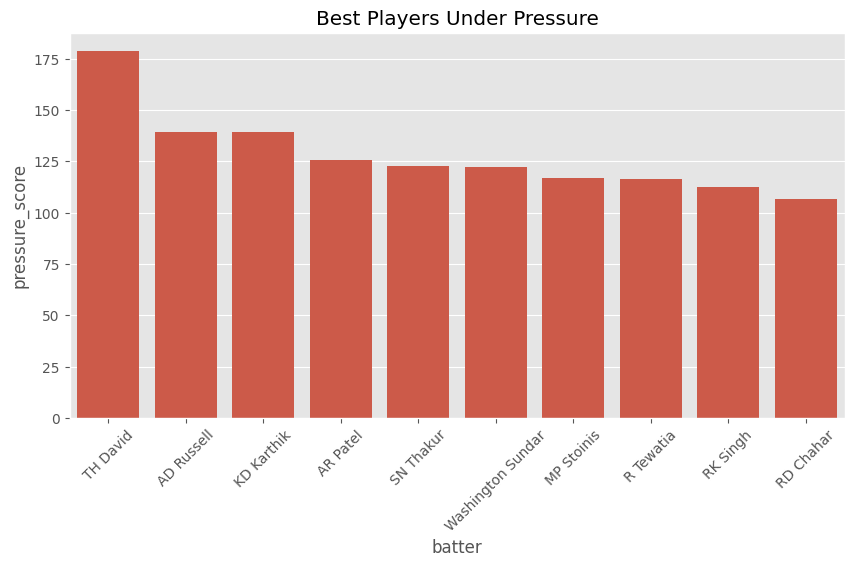

In [20]:
pressure_perf = df.groupby('batter').agg({
    'batsman_run': 'sum',
    'legal_ball': 'sum',
    'pressure_index': 'mean'
}).reset_index()

pressure_perf['strike_rate'] = (pressure_perf['batsman_run'] / pressure_perf['legal_ball']) * 100

# Pressure-adjusted score
pressure_perf['pressure_score'] = pressure_perf['strike_rate'] * pressure_perf['pressure_index']

# Filter players
pressure_perf = pressure_perf[pressure_perf['legal_ball'] > 50]

top_pressure = pressure_perf.sort_values('pressure_score', ascending=False).head(10)

print(top_pressure)

plt.figure(figsize=(10,5))
sns.barplot(data=top_pressure, x='batter', y='pressure_score')
plt.title("Best Players Under Pressure")
plt.xticks(rotation=45)
plt.show()

1)Performed ball-by-ball analysis (~17K deliveries) using Python (Pandas, NumPy) to extract player and team performance insights.

2)Developed phase-based metrics (Powerplay, Middle, Death) to evaluate batsmen strike rate and bowler economy in different match situations.

3)Built a player consistency model using statistical measures (mean, standard deviation) to identify reliable performers.

4)Designed advanced metrics including Finisher Score, Clutch Performance, and Pressure Index to analyze performance under high-pressure scenarios.

5)Generated data-driven insights on match outcomes and impact players, simulating real-world sports analytics use cases